In [1]:
import numpy as np
from matplotlib import pyplot as plt


In [8]:
from dataclasses import dataclass

@dataclass
class Point:
    x: float
    y: float
    z: float =1.0

p = Point([1,2],2)
print(p.x)

[1, 2]


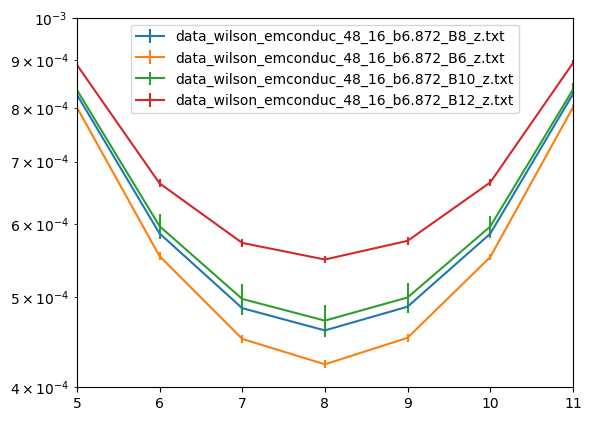

In [99]:
import os
datadir='correlator_finiteT_finiteB/'
lattice_data=[]
dir = os.path.realpath('./')
for file in os.listdir(datadir):
    if file.startswith('data_wilson'):
        lattice_correlator = np.loadtxt(os.path.join(dir,datadir,file))
        x = lattice_correlator[:,0]
        mean=lattice_correlator[:,1]
        error=lattice_correlator[:,2]
        Jackknife_samples = lattice_correlator[:,3:].T
        Nt=16
        zv=.829
        #add first point as last point to make it periodic
        x = np.append(x, len(x))
        mean = np.append(mean, mean[0])
        error = np.append(error, error[0])
        Jackknife_samples = np.append(Jackknife_samples, Jackknife_samples[:,0:1], axis=1)
        numpoints = len(x)
        lattice_data.append([x, mean, error, Jackknife_samples,file])

plotI=[0,4,8,9]
for i,(x,mean,error,_,file) in enumerate(lattice_data):
    if i in plotI:
        plt.errorbar(x, mean, yerr=error,label=file)
plt.yscale('log')
plt.ylim(4e-4,1e-3)
plt.xlim(5,11)
plt.legend()

In [98]:
lattice_data

[[array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
         13., 14., 15., 16.]),
  array([9.53452550e-01, 6.69285157e-02, 1.21433198e-02, 3.44249415e-03,
         1.45197182e-03, 8.26514223e-04, 5.85745835e-04, 4.86700548e-04,
         4.60558524e-04, 4.88448902e-04, 5.85251186e-04, 8.27052999e-04,
         1.45603055e-03, 3.44648724e-03, 1.22292973e-02, 6.72920715e-02,
         9.53452550e-01]),
  array([1.19560361e-03, 2.22862567e-04, 6.95511174e-05, 2.71803551e-05,
         1.41477944e-05, 9.06464511e-06, 5.89503500e-06, 4.93095800e-06,
         4.43096531e-06, 4.67755009e-06, 4.64619977e-06, 6.25984435e-06,
         9.86747091e-06, 1.88707219e-05, 5.39443378e-05, 1.19838357e-04,
         1.19560361e-03]),
  array([[9.52700641e-01, 6.69895396e-02, 1.21754590e-02, 3.45604688e-03,
          1.45670942e-03, 8.29665638e-04, 5.87765921e-04, 4.87692382e-04,
          4.61402778e-04, 4.89364054e-04, 5.85894603e-04, 8.27991611e-04,
          1.45886155e-03, 3.4535323

Text(0.5, 1.0, 'data_wilson_emconduc_48_16_b6.872_B6_z.txt')

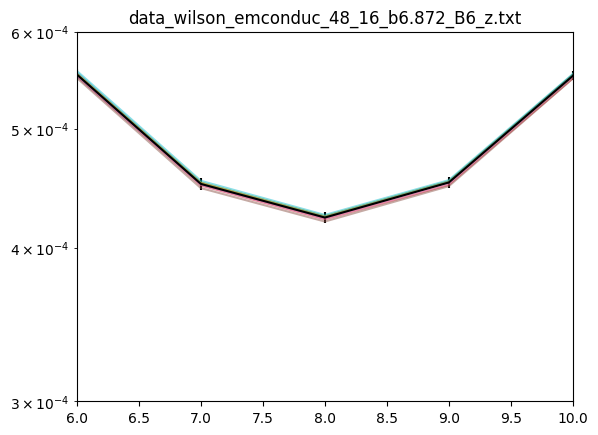

In [3]:
x,mean,error,jack,label=lattice_data[4]

single_lattice_ensemble= []
for i,j in enumerate(jack):
    single_lattice_ensemble.append([x,mean,error,j,"Jack_"+str(i)+"_"+label])

plt.errorbar(x, mean, yerr=error,c='k')
for j in jack:
    plt.plot(x,j,alpha=0.5)
plt.yscale('log')
plt.xlim(6,10)
plt.ylim(3e-4,6e-4)
plt.title(label)

In [3]:
from multiprocessing import Pool

epsilon=1e-10
omega = np.linspace(epsilon,20,500)
del_omega = omega[1]-omega[0]



lambda_s_warmup = 1.0e-5
lambda_l2_warmup = 1.0e-5
lambda_s = 3.55323189e-05#1.0e-5#1.0e-4
lambda_l2 = 6.66754659e-08#1.0e-8
epochs=2000
new_epochs = 100000


def func(lattice_data):

    import models
    import lossCalculator
    import correlator
    import tensorflow as tf


    x, mean, error, Jackknife_samples,file = lattice_data

    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))


    rhoOverOmega_jack_results=[]

    for i,jack in enumerate(Jackknife_samples):
        jackfile="RhoOverOmega_Jack_"+str(i)+"_"+file
        noisy_dxi_tensor = jack
        # noisy_dxi_tensor = mean

        # num_samples = 30
        gauss_width = np.ones(len(x)) #for mean square error
        gauss_width=error
        constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
        kern=klW_ker_Pos


        model = models.SpectralNN(num_output_nodes=500, width=32, depth=3)
        target_output=noisy_dxi_tensor
        lossCalc=lossCalculator.LossCalculator(model=model,
                                            y_true=target_output,
                                            kernel=kern,
                                            delomega=del_omega,
                                            x=constant_input,
                                            std=gauss_width,
                                            lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                            lambda_s_func=lambda x:lambda_s,
                                            lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                            lambda_l2_func=lambda x:lambda_l2
                                                )
        # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
        trainer=models.networkTrainer(model,optimizer,lossCalc)
        total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)

        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4) #notice the lower learning rate
        trainer.optimizer=optimizer
        total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)

        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
        trainer.optimizer=optimizer
        total_loss_history_2,loss_history_2=trainer.train(3000,warmup=False,verbose=True)

        total_loss_history.extend(total_loss_history_2)
        loss_history.extend(loss_history_2)

        rhoOverOmega=model(constant_input)

        rhoOverOmega_jack_results.append([rhoOverOmega])

    rhoOverOmega_jack_results=np.squeeze(np.array(rhoOverOmega_jack_results))
    N=len(Jackknife_samples)
    rhoOverOmega_jackknife_mean=np.squeeze(np.mean(rhoOverOmega_jack_results,axis=0))
    rhoOverOmega_jackknife_error=np.sqrt((N-1)*np.sum((rhoOverOmega_jack_results-rhoOverOmega_jackknife_mean)**2,axis=0)/N)

    total_results=np.column_stack((omega,rhoOverOmega_jackknife_mean,rhoOverOmega_jackknife_error,rhoOverOmega_jack_results.T))

    return [total_results,"RhoOverOmega_meanTraining_Jackknife_"+file]




In [4]:


pool=Pool(13)
jackedResults=pool.map(func,lattice_data)

# results.wait()

pool.close()
# rhoOverOmega_list=np.array(rhoOverOmega_list)
# total_loss_history_list=np.array(total_loss_history_list)
# loss_history_list=np.array(loss_history_list)
# x=np.array(x)
# noisy_Dxi=np.array(noisy_Dxi)
# error=np.array(error)
# file=np.array(file)


outputdir="correlator_finiteT_finiteB/jackknife_meanTraining/"

for res,file in jackedResults:
    headerstring="omega,Mean_Jackknife,Error_Jackknife"
    for i in range(res.shape[1]-2):
        headerstring+=",Jackknife_"+str(i)
    np.savetxt(outputdir+"RhoOverOmega_meanTraining_"+file,res,header=headerstring)

2025-01-23 15:48:04.503926: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-23 15:48:04.503925: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-23 15:48:04.503925: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-23 15:48:04.503926: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly 

Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs
Training for 2000 epochs


2025-01-23 15:48:05.498214: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:05.513499: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:05.514455: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:05.546070: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:05.599246: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:05.640897: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1

Epoch 0, Loss: 2271.43798828125
Epoch 0, Loss: 2270.487060546875
Epoch 0, Loss: 2287.417724609375
Epoch 0, Loss: 2301.126220703125
Training for 2000 epochsEpoch 0, Loss: 2276.15966796875

Training for 2000 epochs
Epoch 0, Loss: 2277.645751953125
Training for 2000 epochs

2025-01-23 15:48:05.805195: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:05.812435: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:05.974327: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Epoch 0, Loss: 2284.849365234375
Epoch 0, Loss: 2254.838134765625
Training for 2000 epochs
Training for 2000 epochs
Epoch 0, Loss: 2293.474365234375
Training for 2000 epochs


2025-01-23 15:48:06.023358: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:06.099320: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-23 15:48:06.157801: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 0, Loss: 2266.520263671875
Epoch 0, Loss: 2285.062744140625
Epoch 0, Loss: 2291.15087890625
Training for 2000 epochs
Epoch 0, Loss: 2307.715576171875


2025-01-23 15:48:06.389086: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 200, Loss: 1.996820330619812
Epoch 200, Loss: 1.7811826467514038
Epoch 200, Loss: 1.970078468322754
Epoch 200, Loss: 1.784021258354187
Epoch 200, Loss: 2.3290297985076904
Epoch 200, Loss: 1.7681175470352173
Epoch 200, Loss: 2.19714617729187
Epoch 200, Loss: 1.8866106271743774
Epoch 200, Loss: 1.6229102611541748
Epoch 400, Loss: 0.4147967994213104
Epoch 200, Loss: 1.4526468515396118
Epoch 400, Loss: 0.3359740078449249
Epoch 400, Loss: 0.36976274847984314
Epoch 400, Loss: 0.4193424582481384
Epoch 200, Loss: 2.3155019283294678
Epoch 400, Loss: 0.4698832929134369
Epoch 200, Loss: 2.2308900356292725
Epoch 400, Loss: 0.37988537549972534
Epoch 400, Loss: 0.4435334801673889
Epoch 200, Loss: 2.411106586456299
Epoch 400, Loss: 0.31512001156806946
Epoch 400, Loss: 0.41065552830696106
Epoch 600, Loss: 0.15839913487434387
Epoch 600, Loss: 0.15836703777313232
Epoch 600, Loss: 0.13761506974697113
Epoch 600, Loss: 0.1502181589603424
Epoch 400, Loss: 0.45987215638160706
Epoch 600, Loss: 0.1608458

In [26]:

# outputdir="correlator_finiteT_finiteB/jackknife_meanTraining/"

# for res,file in jackedResults:
#     headerstring="omega,Mean_Jackknife,Error_Jackknife"
#     for i in range(res.shape[1]-2):
#         headerstring+=",Jackknife_"+str(i)
#     np.savetxt(outputdir+"RhoOverOmega_meanTraining_"+file,np.column_stack((omega,res)),header=headerstring)

In [71]:
jackedResults

In [8]:
file

array(['data_wilson_emconduc_48_16_b6.872_B8_z.txt',
       'data_wilson_emconduc_48_16_b6.872_B4_z.txt',
       'data_wilson_emconduc_48_16_b6.872_B4_x.txt',
       'data_wilson_emconduc_48_16_b6.872_B12_x.txt',
       'data_wilson_emconduc_48_16_b6.872_B6_z.txt',
       'data_wilson_emconduc_48_16_b6.872_B2_z.txt',
       'data_wilson_emconduc_48_16_b6.872_B10_x.txt',
       'data_wilson_emconduc_48_16_b6.872_B0_x.txt',
       'data_wilson_emconduc_48_16_b6.872_B10_z.txt',
       'data_wilson_emconduc_48_16_b6.872_B12_z.txt',
       'data_wilson_emconduc_48_16_b6.872_B8_x.txt',
       'data_wilson_emconduc_48_16_b6.872_B6_x.txt',
       'data_wilson_emconduc_48_16_b6.872_B2_x.txt'], dtype='<U43')

In [53]:
meanTraining_jackknife=np.array([
[np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B0_x.txt'),
np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B0_z.txt'),],
[np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B2_x.txt'),
np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B2_z.txt'),],
[np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B4_x.txt'),
np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B4_z.txt'),],
[np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B6_x.txt'),
np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B6_z.txt'),],
[np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B8_x.txt'),
np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B8_z.txt'),],
[np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B10_x.txt'),
np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B10_z.txt'),],
[np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B12_x.txt'),
np.loadtxt('correlator_finiteT_finiteB/jackknife_meanTraining/RhoOverOmega_meanTraining_Jackknife_data_wilson_emconduc_48_16_b6.872_B12_z.txt'),],
])

def jackKnifeError(jackknife_samples):
    mean = np.mean(jackknife_samples[:,:,1],axis=0)
    N = len(jackknife_samples)
    return np.column_stack((jackknife_samples[:,0],mean)),np.sqrt((N-1)*np.sum((jackknife_samples[:,1]-mean)**2,axis=0)/N)

meantraining_jackknife_results=meanTraining_jackknife[:,:,:,:3]

Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

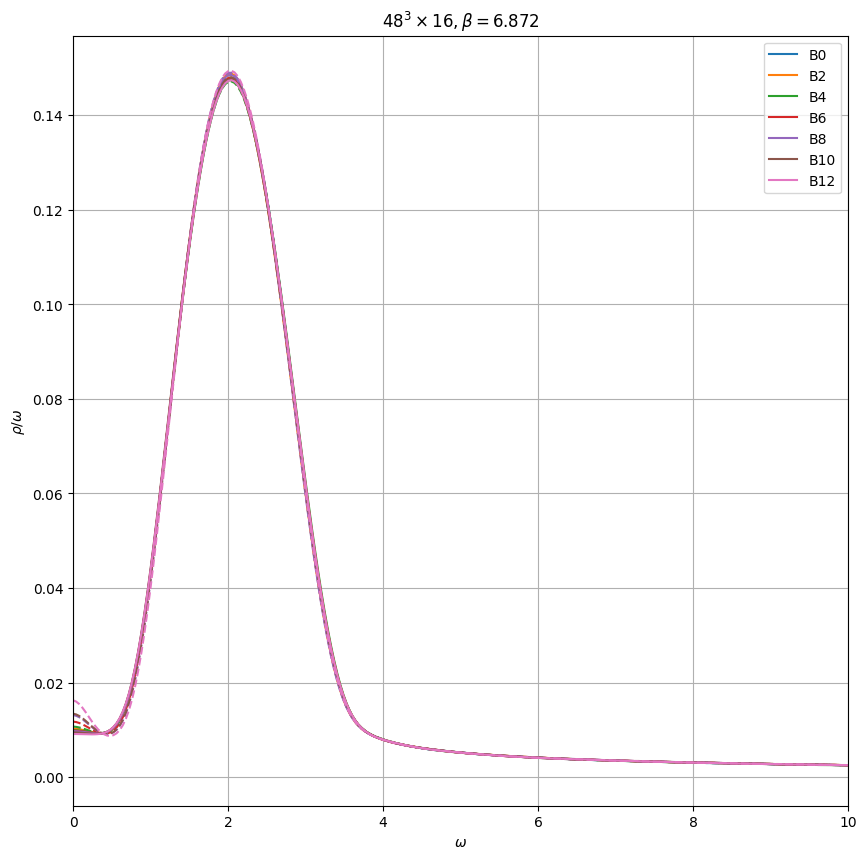

In [35]:
import matplotlib.pyplot as plt
import numpy as np
Nt=16
files=[
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B0_x.txt",
"correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B0_x.txt","B0"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B2_x.txt",
"correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B2_z.txt","B2"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B4_x.txt",
"correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B4_z.txt","B4"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B6_x.txt",
"correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B6_z.txt","B6"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B8_x.txt",
"correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B8_z.txt","B8"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B10_x.txt",
"correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B10_z.txt","B10"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B12_x.txt",
"correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B12_z.txt","B12"],
]

f=plt.figure()
f.set_size_inches(10,10)
zv=.829
colors=['C0','C1','C2','C3','C4','C5','C6']
for (file1,file2,label),c in zip(files,colors):
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    plt.plot(dat1[:,0],dat1[:,1], label=label,color=c)
    plt.plot(dat2[:,0],dat2[:,1],ls='--',color=c)
plt.xlim(0,10.0)
# plt.ylim(0.005,0.02)
plt.grid()
plt.legend()
plt.ylabel(r'$\rho/\omega$')
plt.xlabel(r'$\omega$')
plt.title(r'$48^3\times 16, \beta=6.872$')

In [30]:
dean_rhoOverOmega_files=[
    ["correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B0_x.dat",
     "correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B0_x.dat","B0"],
    ["correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B2_x.dat",
     "correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B2_z.dat","B2"],
    ["correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B4_x.dat",
     "correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B4_z.dat","B4"],
    ["correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B6_x.dat",
     "correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B6_z.dat","B6"],
    ["correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B8_x.dat",
     "correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B8_z.dat","B8"],
    ["correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B10_x.dat",
     "correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B10_z.dat","B10"],
    ["correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B12_x.dat",
     "correlator_finiteT_finiteB/dean_gauss_results/spec_func_48_16_b6.872_B12_z.dat","B12"],
]

rhoOverOmega_files=[
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B0_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B0_x.txt","B0"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B2_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B2_z.txt","B2"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B4_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B4_z.txt","B4"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B6_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B6_z.txt","B6"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B8_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B8_z.txt","B8"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B10_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B10_z.txt","B10"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B12_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B12_z.txt","B12"],
]

rhoOverOmega_meanTraining_files=[
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B0_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B0_x.txt","B0"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_z.txt","B2"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B4_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B4_z.txt","B4"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B6_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B6_z.txt","B6"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B8_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B8_z.txt","B8"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B10_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B10_z.txt","B10"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B12_x.txt",
 "correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_meanTraining_data_wilson_emconduc_48_16_b6.872_B12_z.txt","B12"],
]

dean_rhoOverOmega=[]
for file1,file2,label in dean_rhoOverOmega_files:
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    dean_rhoOverOmega.append([dat1,dat2,label])

rhoOverOmega=[]
for file1,file2,label in rhoOverOmega_files:
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    rhoOverOmega.append([dat1,dat2,label])

rhoOverOmega_meanTraining=[]
for file1,file2,label in rhoOverOmega_meanTraining_files:
    dat1 = np.loadtxt(file1)
    dat2 = np.loadtxt(file2)
    rhoOverOmega_meanTraining.append([dat1,dat2,label])

Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

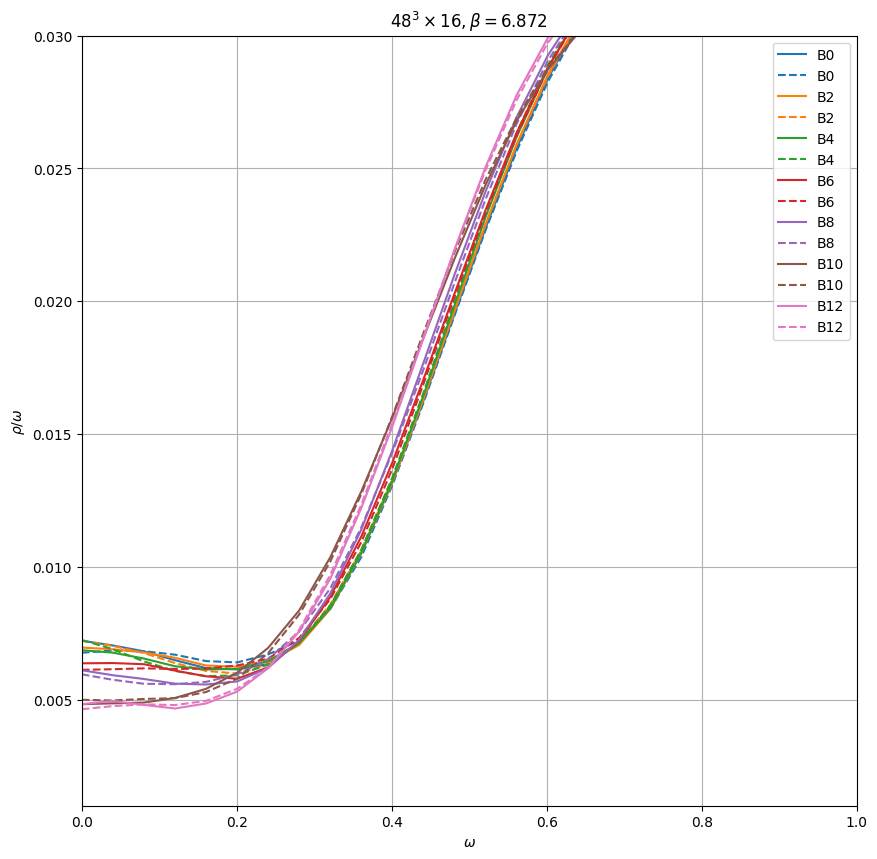

In [15]:
import matplotlib.pyplot as plt
import numpy as np
Nt=16


f=plt.figure()
f.set_size_inches(10,10)
zv=.829
colors=['C0','C1','C2','C3','C4','C5','C6']
for (dat1,dat2,label),(ddat1,ddat2,label),(mTdat1,mTdat2,label),c in zip(rhoOverOmega,dean_rhoOverOmega,rhoOverOmega_meanTraining,colors):
    plt.plot(dat1[:,0],dat1[:,1], label=label,color=c)
    # plt.plot(dat2[:,0],dat2[:,1],ls='--',color=c)
    plt.plot(mTdat1[:,0],mTdat1[:,1], label=label,color=c,ls='--')

plt.xlim(0,10.0)
# plt.ylim(0.005,0.02)
plt.xlim(0,1.0)
plt.ylim(0.001,0.03)
plt.grid()
plt.legend()
plt.ylabel(r'$\rho/\omega$')
plt.xlabel(r'$\omega$')
plt.title(r'$48^3\times 16, \beta=6.872$')

/tmp/ipykernel_100587/3963462145.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

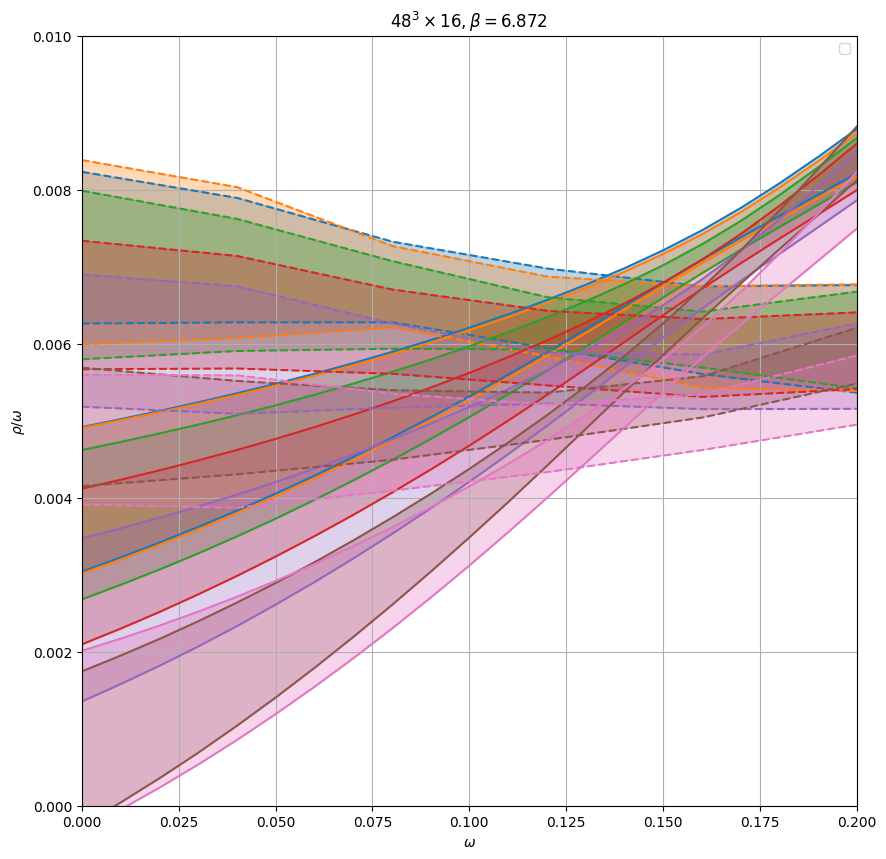

In [84]:
import matplotlib.pyplot as plt
import numpy as np
Nt=16


f=plt.figure()
f.set_size_inches(10,10)
zv=.829
colors=['C0','C1','C2','C3','C4','C5','C6']

xPlot=False
zPlot=False

xPlot=not zPlot

for (jackdatx,jackdatz),(deandatx,deandatz,label),c in zip(meantraining_jackknife_results,dean_rhoOverOmega,colors):
    if xPlot:
        plt.fill_between(deandatx[:,0],deandatx[:,1]-deandatx[:,2],deandatx[:,1]+deandatx[:,2],color=c,alpha=0.3)
        plt.plot(deandatx[:,0],deandatx[:,1]+deandatx[:,2],color=c)
        plt.plot(deandatx[:,0],deandatx[:,1]-deandatx[:,2],color=c)
        plt.fill_between(jackdatx[:,0],jackdatx[:,1]-jackdatx[:,2],jackdatx[:,1]+jackdatx[:,2],color=c,alpha=0.3)
        plt.plot(jackdatx[:,0],jackdatx[:,1]+jackdatx[:,2],color=c,ls='--')
        plt.plot(jackdatx[:,0],jackdatx[:,1]-jackdatx[:,2],color=c,ls='--')

    if zPlot:
        plt.fill_between(deandatz[:,0],deandatz[:,1]-deandatz[:,2],deandatz[:,1]+deandatz[:,2],color=c,alpha=0.3)
        plt.plot(deandatz[:,0],deandatz[:,1]+deandatz[:,2],color=c) 
        plt.plot(deandatz[:,0],deandatz[:,1]-deandatz[:,2],color=c)
        plt.fill_between(jackdatz[:,0],jackdatz[:,1]-jackdatz[:,2],jackdatz[:,1]+jackdatz[:,2],color=c,alpha=0.3)
        plt.plot(jackdatz[:,0],jackdatz[:,1]+jackdatz[:,2],color=c,ls='--')
        plt.plot(jackdatz[:,0],jackdatz[:,1]-jackdatz[:,2],color=c,ls='--')
plt.xlim(0,10.0)
# plt.ylim(0.005,0.02)
plt.xlim(0,0.2)
plt.ylim(0.0000,0.01)
plt.grid()
plt.legend()
plt.ylabel(r'$\rho/\omega$')
plt.xlabel(r'$\omega$')
plt.title(r'$48^3\times 16, \beta=6.872$')

/tmp/ipykernel_100587/1501937835.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

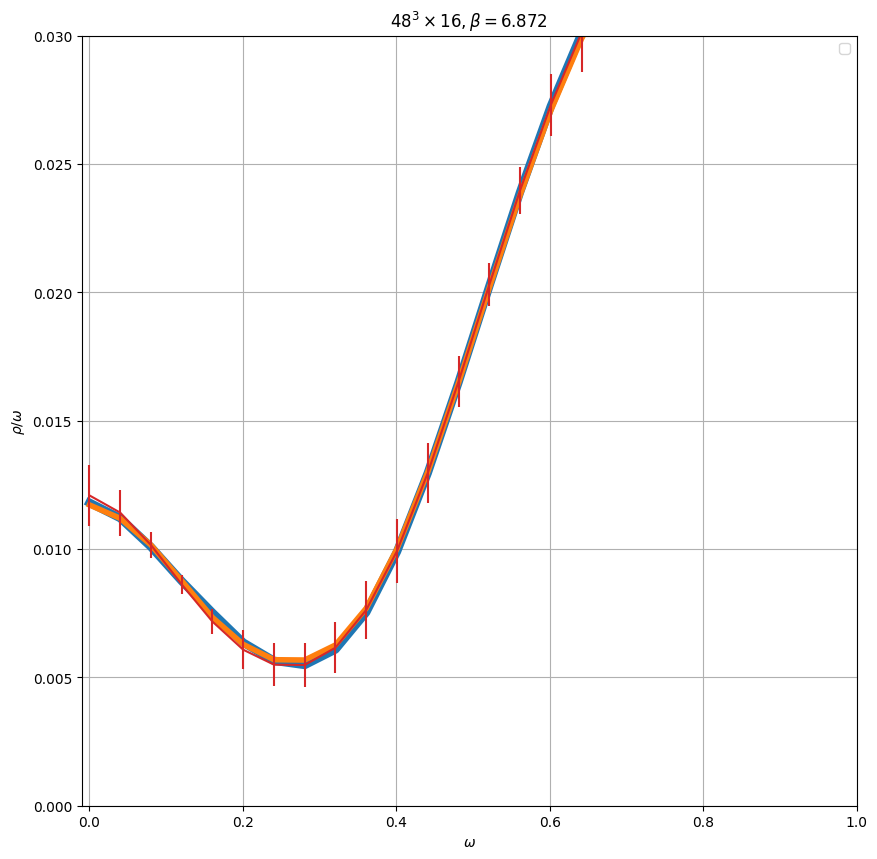

In [56]:
import matplotlib.pyplot as plt
import numpy as np
Nt=16


f=plt.figure()
f.set_size_inches(10,10)
zv=.829
colors=['C0','C1','C2','C3','C4','C5','C6']
i=3

_,dat2,_=rhoOverOmega[i]
_,mTdat2,_=rhoOverOmega_meanTraining[i]
_,ddat2,_=dean_rhoOverOmega[i]


plt.plot(dat2[:,0],dat2[:,1],ls='-',lw=6)
plt.plot(mTdat2[:,0],mTdat2[:,1],ls='-',lw=4)
# plt.fill_between(ddat1[:,0],ddat1[:,1]-ddat1[:,2],ddat1[:,1]+ddat1[:,2],color=c,alpha=0.3)
# plt.fill_between(ddat2[:,0],ddat2[:,1]-ddat2[:,2],ddat2[:,1]+ddat2[:,2],alpha=0.3,color='C2')

# for jack in B6zjackData:
#     plt.plot(jack[:,0],jack[:,1],ls='-',alpha=0.3,color='gray')

# plt.errorbar(jackknife_mean[:,0],jackknife_mean[:,1],yerr=jackknife_error,ls='-',color='C3')

plt.errorbar(meantraining_jackknife_results[i][1][:,0],meantraining_jackknife_results[i][1][:,1],yerr=meantraining_jackknife_results[i][1][:,2],ls='-',color='C3')


# plt.ylim(0.005,0.02)
plt.xlim(-0.01,1.0)
plt.ylim(0.0000,0.03)
plt.grid()
plt.legend()
plt.ylabel(r'$\rho/\omega$')
plt.xlabel(r'$\omega$')
plt.title(r'$48^3\times 16, \beta=6.872$')

In [58]:
dean_results=[
    np.loadtxt('correlator_finiteT_finiteB/dean_gauss_results/elec_cond_x_beta5.845.dat'),
    np.loadtxt('correlator_finiteT_finiteB/dean_gauss_results/elec_cond_z_beta5.845.dat'),
    np.loadtxt('correlator_finiteT_finiteB/dean_gauss_results/elec_cond_x_beta6.872.dat'),
    np.loadtxt('correlator_finiteT_finiteB/dean_gauss_results/elec_cond_z_beta6.872.dat'),
]


Text(0.5, 1.0, '$48^3\\times 16, \\beta=6.872$')

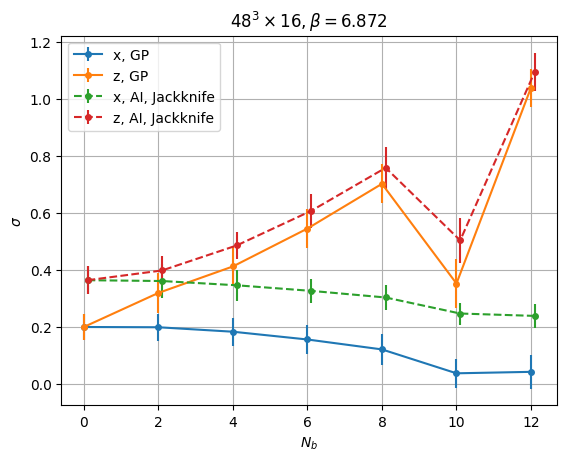

In [83]:
f=plt.figure()
# f.set_size_inches(10,10)
# zv=.829
epsilon=0.1
Nt=16
colors=['C0','C1','C2','C3','C4','C5','C6']
zdat=[]
xdat=[]
mTzdat=[]
mTxdat=[]
for (xDat,zDat,Label) in rhoOverOmega:
    xdat.append(xDat[0,1])
    zdat.append(zDat[0,1])
for (xDat,zDat,Label) in rhoOverOmega_meanTraining:
    mTxdat.append(xDat[0,1])
    mTzdat.append(zDat[0,1])

zdat=np.array(zdat)
xdat=np.array(xdat)
mTzdat=np.array(mTzdat)
mTxdat=np.array(mTxdat)

factor=Nt*np.pi

brange=np.array([0,2,4,6,8,10,12])
# plt.plot(brange,zdat*Nt*np.pi-zdat[0]*Nt*np.pi,'o-',label=r'z, AI')
# plt.plot(brange,xdat*Nt*np.pi-zdat[0]*Nt*np.pi,'o-',label=r'x, AI')
# plt.plot(brange,mTzdat*Nt*np.pi-mTzdat[0]*Nt*np.pi,'o--',label=r'z, AI, meanTraining')
# plt.plot(brange,mTxdat*Nt*np.pi-mTxdat[0]*Nt*np.pi,'o--',label=r'x, AI, meanTraining')
diff=False
if diff:
    deanshift=dean_results[2][:,1][0]
    aishift=meantraining_jackknife_results[0,0,0,1]*factor
    plt.ylabel(r'$\sigma-\sigma|_{N_b=0}$')
else:
    deanshift=0
    aishift=0
    plt.ylabel(r'$\sigma$')

plt.errorbar(brange,dean_results[2][:,1]-deanshift,yerr=dean_results[2][:,2],label=r'x, GP',marker='o',markersize=4)
plt.errorbar(brange,dean_results[3][:,1]-deanshift,yerr=dean_results[3][:,2],label=r'z, GP',marker='o',markersize=4)

plt.errorbar(brange+epsilon,meantraining_jackknife_results[:,0,0,1]*factor-aishift,yerr=meantraining_jackknife_results[:,0,0,2]*factor,ls='--',label=r'x, AI, Jackknife',marker='o',markersize=4)
plt.errorbar(brange+epsilon,meantraining_jackknife_results[:,1,0,1]*factor-aishift,yerr=meantraining_jackknife_results[:,1,0,2]*factor,ls='--',label=r'z, AI, Jackknife',marker='o',markersize=4)


plt.grid()
plt.legend()

plt.xlabel(r'$N_b$')
plt.title(r'$48^3\times 16, \beta=6.872$')

In [12]:
import correlator
import numpy as np
import matplotlib.pyplot as plt

epsilon=1e-10
omega = np.linspace(epsilon,20,500)
del_omega = omega[1]-omega[0]
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))
allFiles=[
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B0_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B0_x.txt", "B0, x"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B0_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B0_x.txt", "B0, z"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B2_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B2_x.txt", "B2, x"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B2_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B2_z.txt", "B2, z"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B4_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B4_x.txt", "B4, x"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B4_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B4_z.txt", "B4, z"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B6_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B6_x.txt", "B6, x"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B6_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B6_z.txt", "B6, z"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B8_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B8_x.txt", "B8, x"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B8_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B8_z.txt", "B8, z"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B10_x.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B10_x.txt","B10, x"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B10_z.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B10_z.txt","B10, z"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B12_x.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B12_x.txt","B12, x"],
["correlator_finiteT_finiteB/RhoOverOmega_data_wilson_emconduc_48_16_b6.872_B12_z.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B12_z.txt","B12, z"],
]

lattice_data=[]
reconstructed_data=[]
for rhoFile,correlatorFile,Label in allFiles:        
    lattice_correlator = np.loadtxt(correlatorFile)
    x = lattice_correlator[:,0]
    mean=lattice_correlator[:,1]
    error=lattice_correlator[:,2]
    Jackknife_samples = lattice_correlator[:,3:].T
    Nt=16
    zv=.829
    #add first point as last point to make it periodic
    x = np.append(x, len(x))
    mean = np.append(mean, mean[0])
    error = np.append(error, error[0])
    Jackknife_samples = np.append(Jackknife_samples, Jackknife_samples[:,0:1], axis=1)
    numpoints = len(x)
    lattice_data.append([x, mean, error, Jackknife_samples,Label])
    rhoOverOmega = np.loadtxt(rhoFile)
    rhoOverOmega = rhoOverOmega[:,1]
    Dxi_reconstructed = correlator.Di(klW_ker_Pos,rhoOverOmega,del_omega)
    reconstructed_data.append([x,Dxi_reconstructed,Label])


/tmp/ipykernel_30367/796913344.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


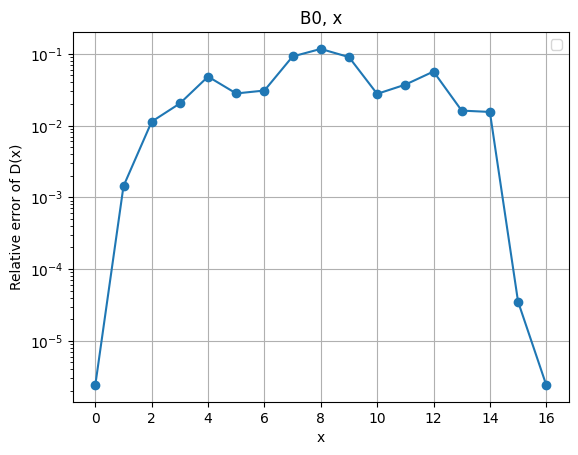

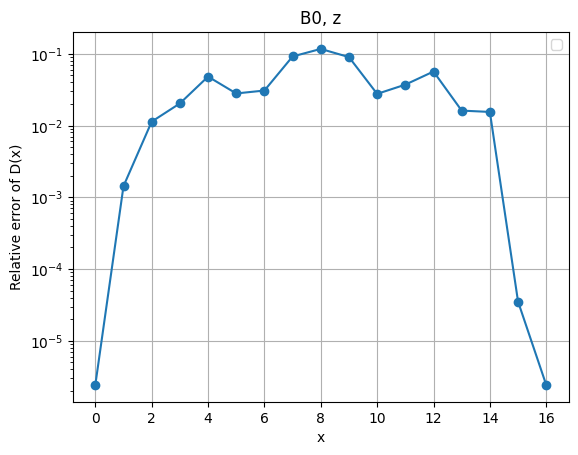

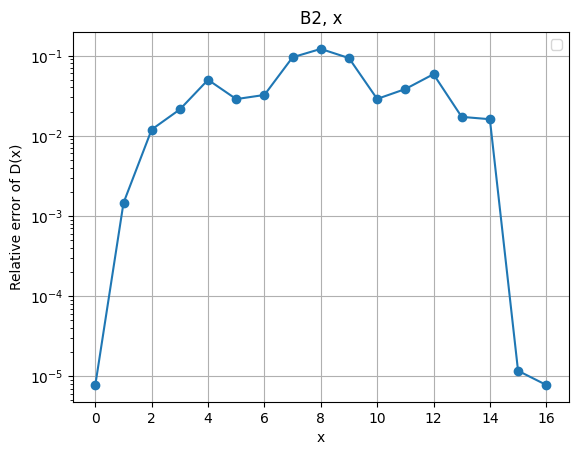

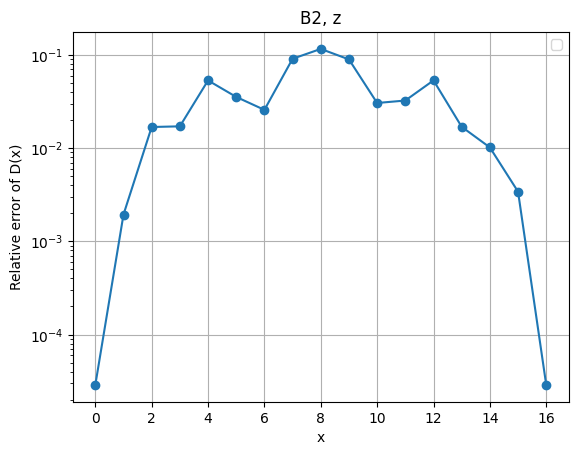

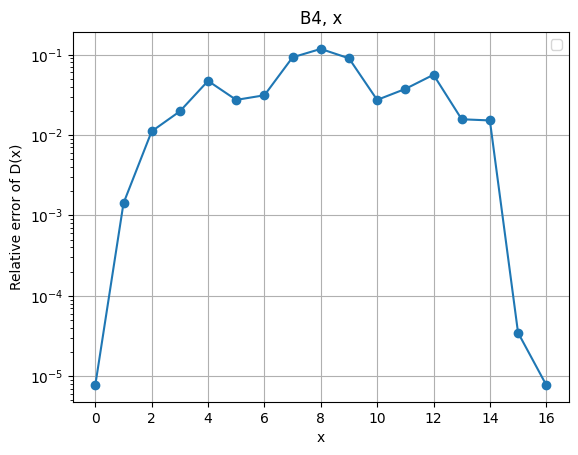

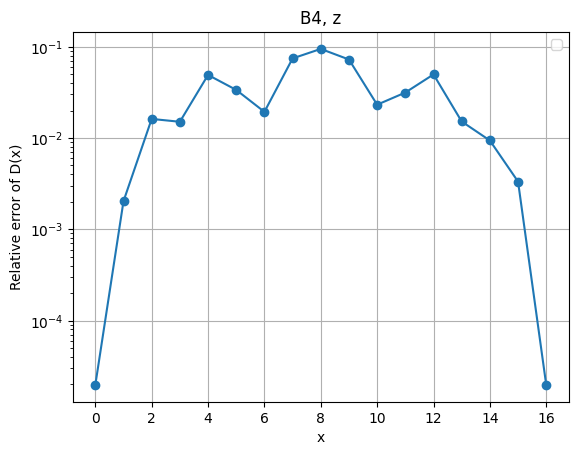

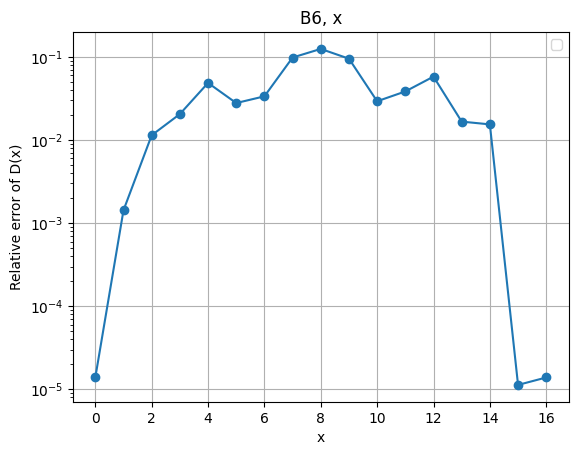

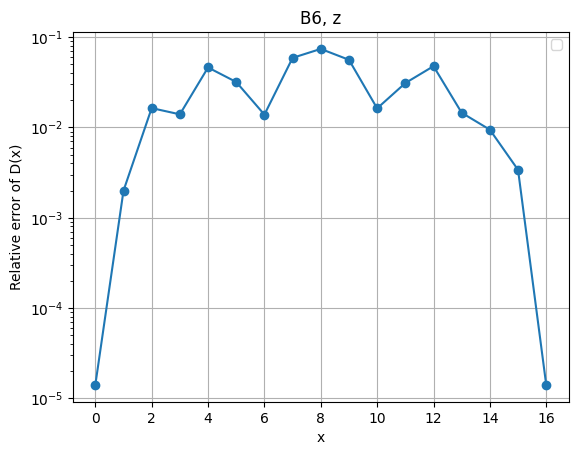

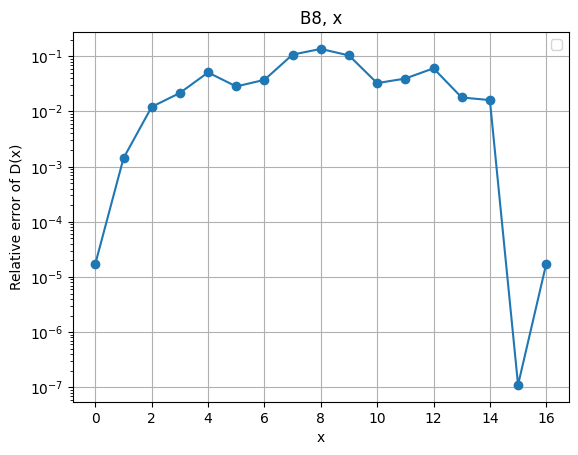

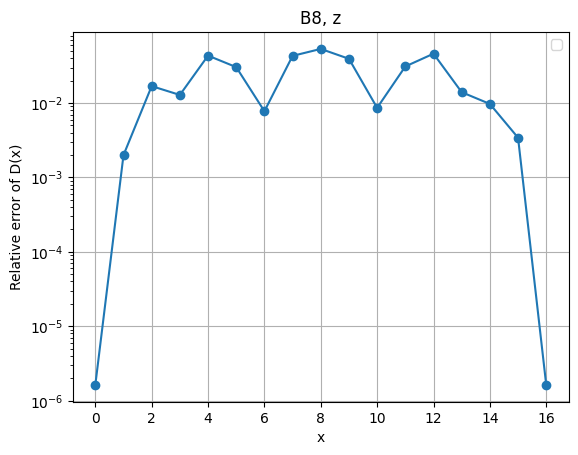

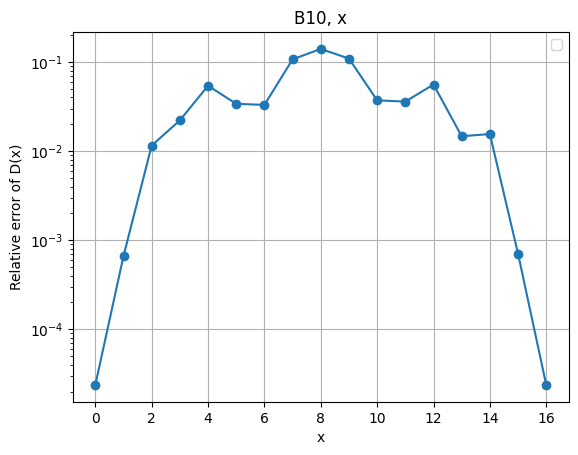

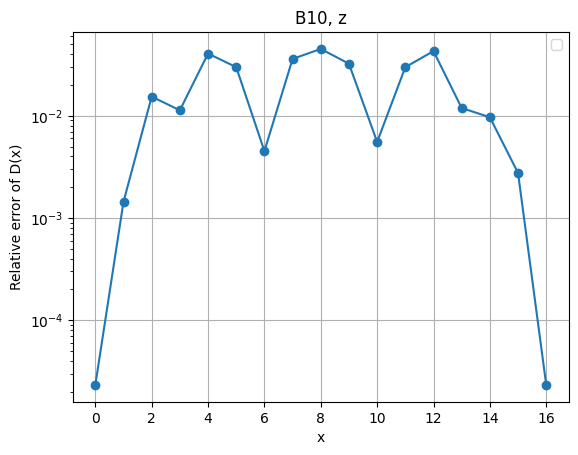

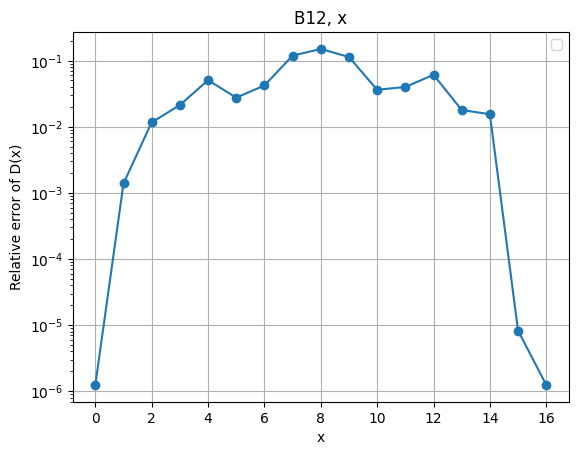

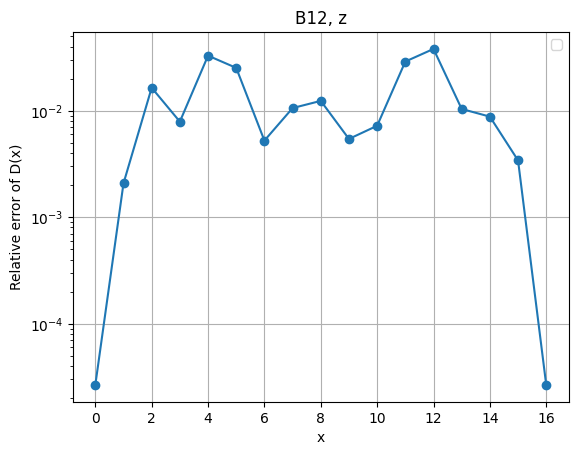

In [13]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    # plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    # plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    plt.plot(x,np.abs(mean-Dxi_reconstructed)/mean,'o-')
    plt.title(Label)
    plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('Relative error of D(x)')
    plt.grid()
    plt.legend()
    # plt.ylim(1e-4,1e0)

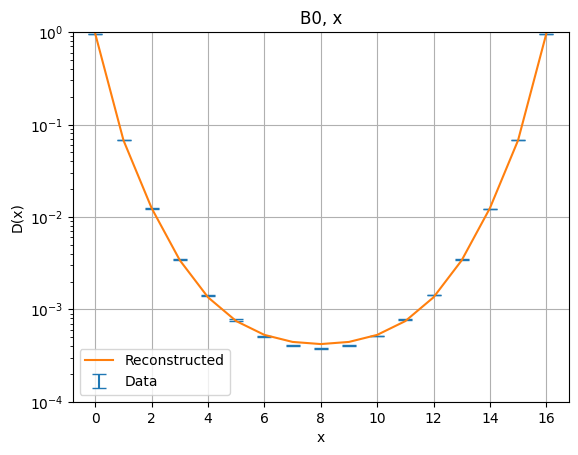

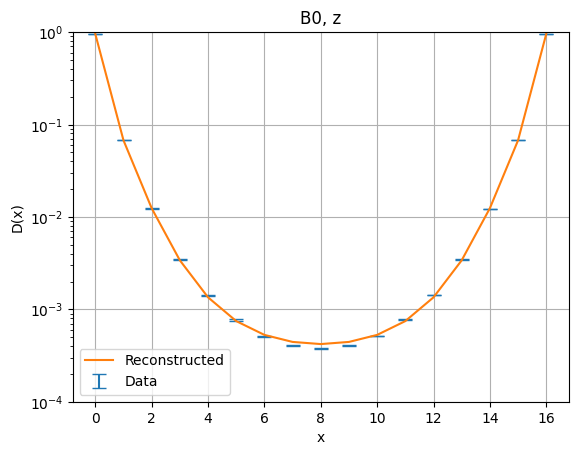

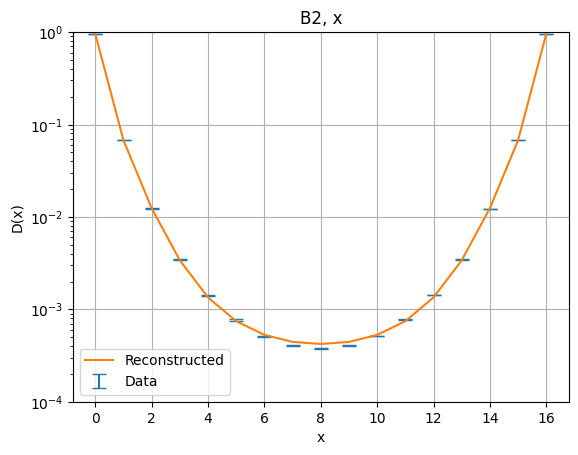

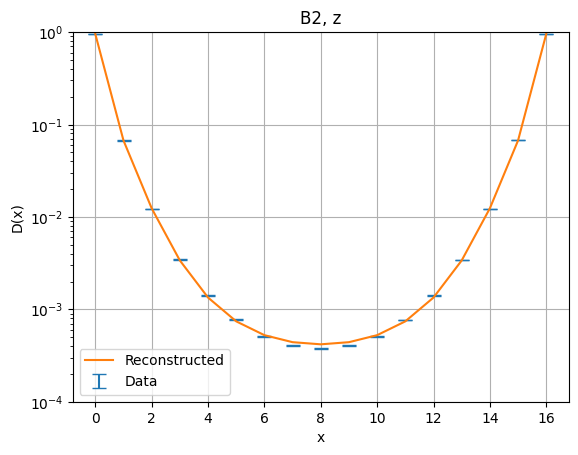

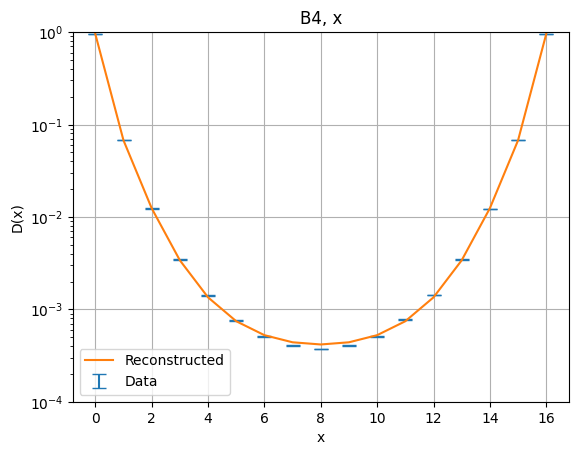

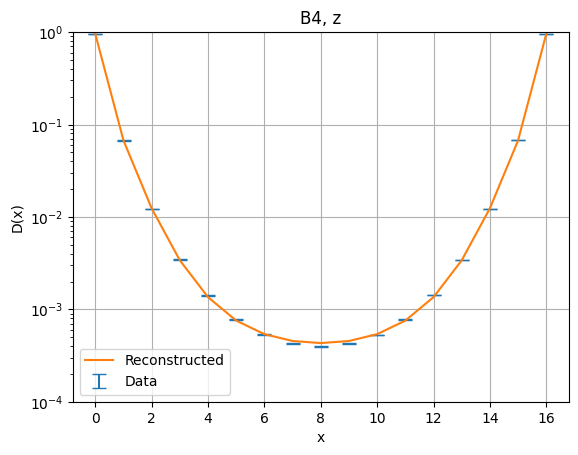

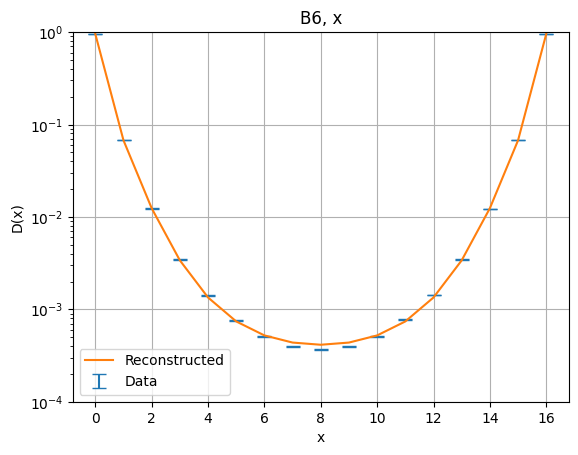

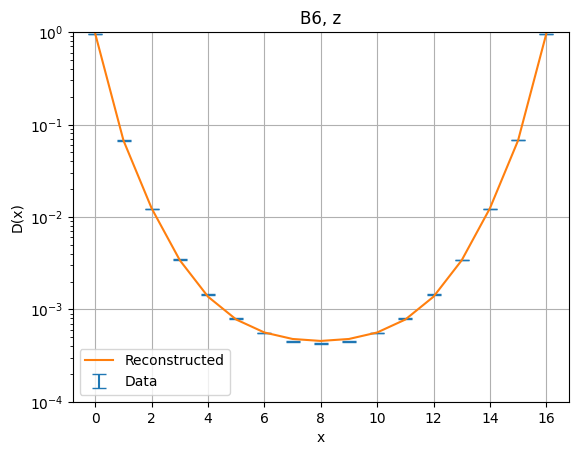

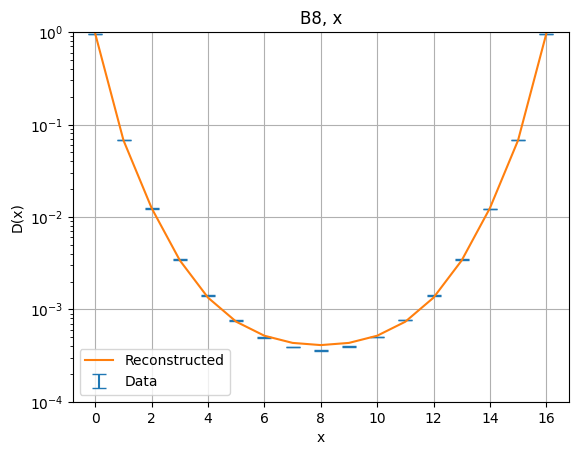

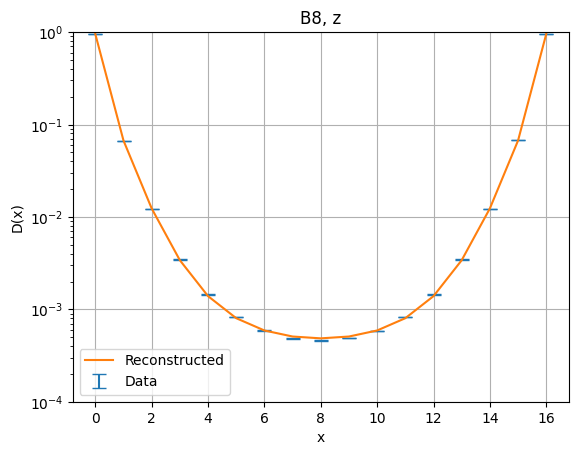

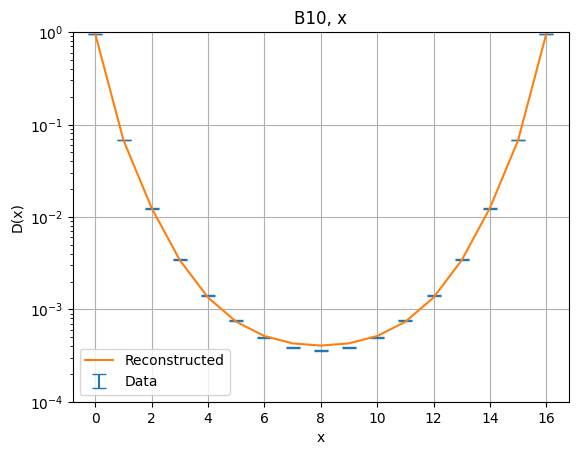

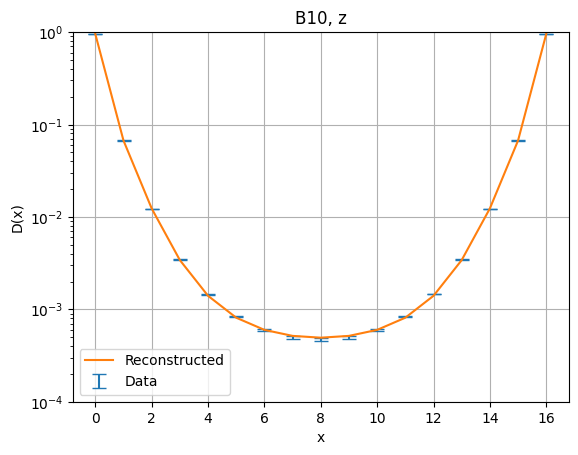

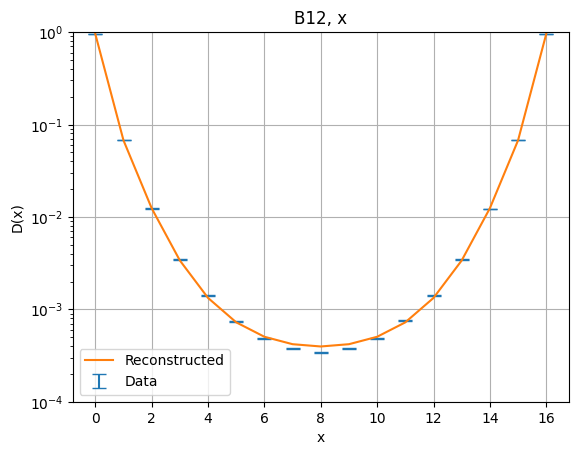

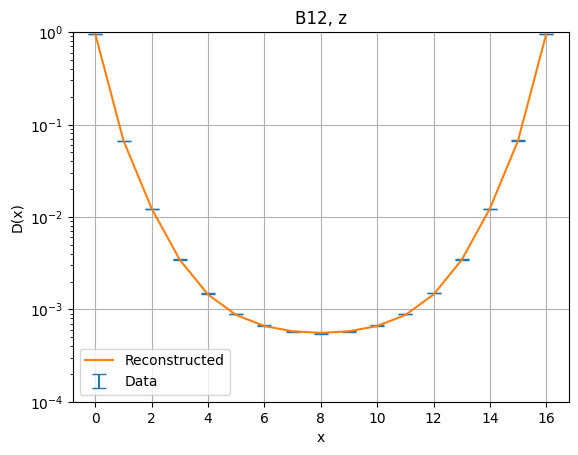

In [48]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    # plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    # plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    plt.title(Label)
    plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('D(x)')
    plt.grid()
    plt.legend()
    plt.ylim(1e-4,1e0)

In [5]:
import correlator

epsilon=1e-10
omega = np.linspace(epsilon,20,500)
del_omega = omega[1]-omega[0]
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))
allFilesErrorWeighting=[
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B0_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B0_x.txt", "B0, x"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B0_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B0_x.txt", "B0, z"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B2_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B2_x.txt", "B2, x"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B2_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B2_z.txt", "B2, z"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B4_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B4_x.txt", "B4, x"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B4_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B4_z.txt", "B4, z"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B6_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B6_x.txt", "B6, x"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B6_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B6_z.txt", "B6, z"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B8_x.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B8_x.txt", "B8, x"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B8_z.txt", "correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B8_z.txt", "B8, z"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B10_x.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B10_x.txt","B10, x"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B10_z.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B10_z.txt","B10, z"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B12_x.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B12_x.txt","B12, x"],
["correlator_finiteT_finiteB/RhoOverOmega_errorWeighting_data_wilson_emconduc_48_16_b6.872_B12_z.txt","correlator_finiteT_finiteB/data_wilson_emconduc_48_16_b6.872_B12_z.txt","B12, z"],
]

lattice_data=[]
reconstructed_data=[]
for rhoFile,correlatorFile,Label in allFilesErrorWeighting:        
    lattice_correlator = np.loadtxt(correlatorFile)
    x = lattice_correlator[:,0]
    mean=lattice_correlator[:,1]
    error=lattice_correlator[:,2]
    Jackknife_samples = lattice_correlator[:,3:].T
    Nt=16
    zv=.829
    #add first point as last point to make it periodic
    x = np.append(x, len(x))
    mean = np.append(mean, mean[0])
    error = np.append(error, error[0])
    Jackknife_samples = np.append(Jackknife_samples, Jackknife_samples[:,0:1], axis=1)
    numpoints = len(x)
    lattice_data.append([x, mean, error, Jackknife_samples,Label])
    rhoOverOmega = np.loadtxt(rhoFile)
    rhoOverOmega = rhoOverOmega[:,1]
    Dxi_reconstructed = correlator.Di(klW_ker_Pos,rhoOverOmega,del_omega)
    reconstructed_data.append([x,Dxi_reconstructed,Label])


2025-01-22 15:23:44.491321: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


/tmp/ipykernel_40550/1538946904.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


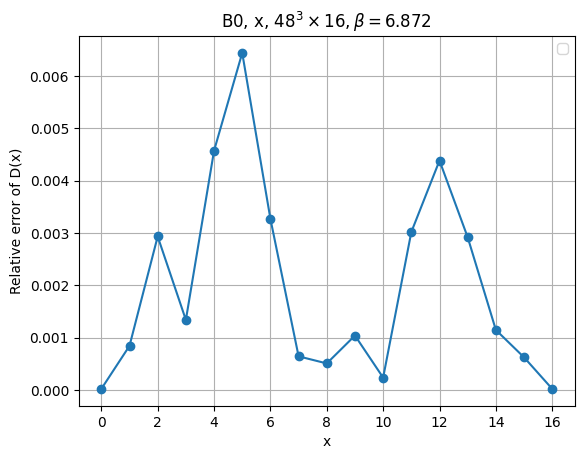

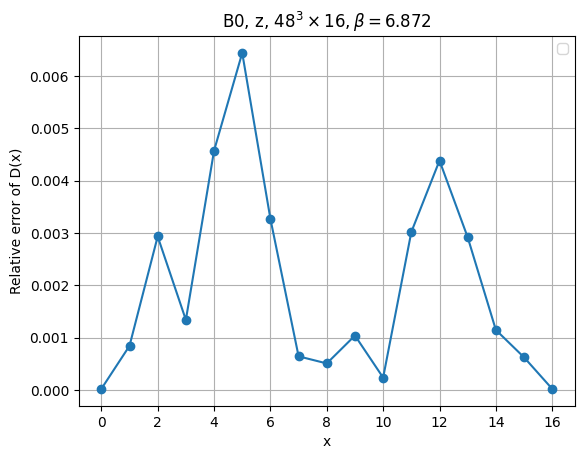

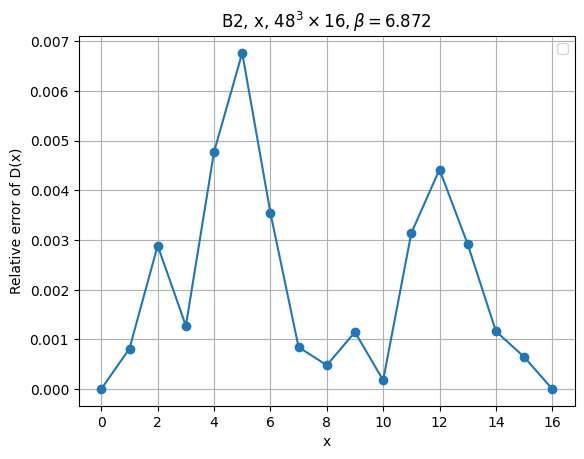

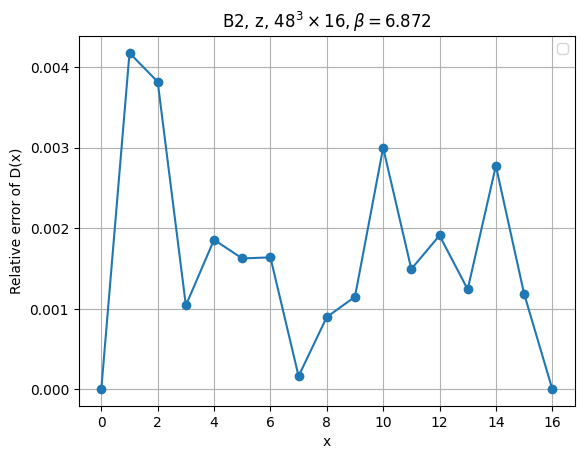

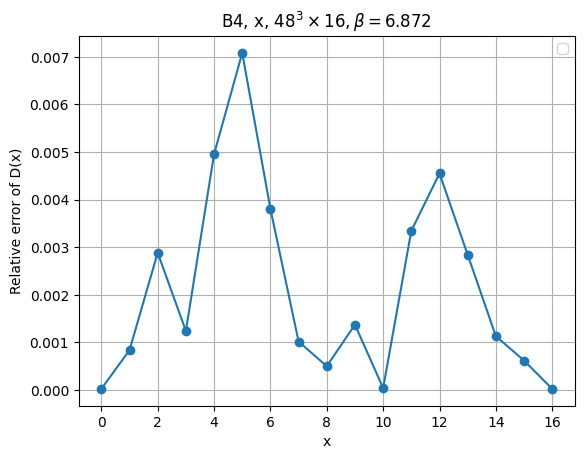

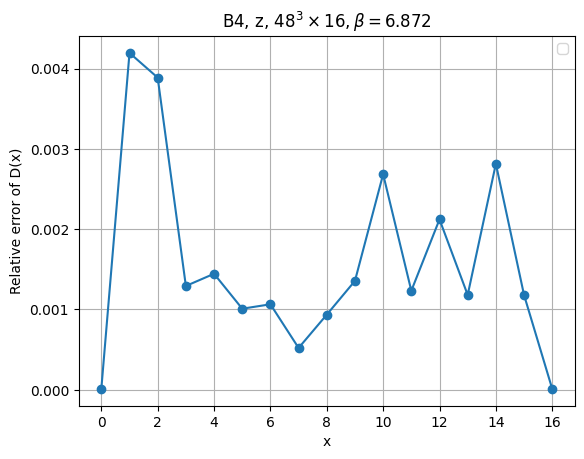

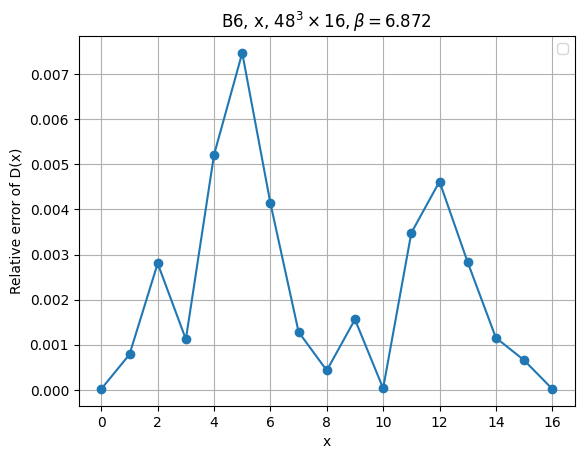

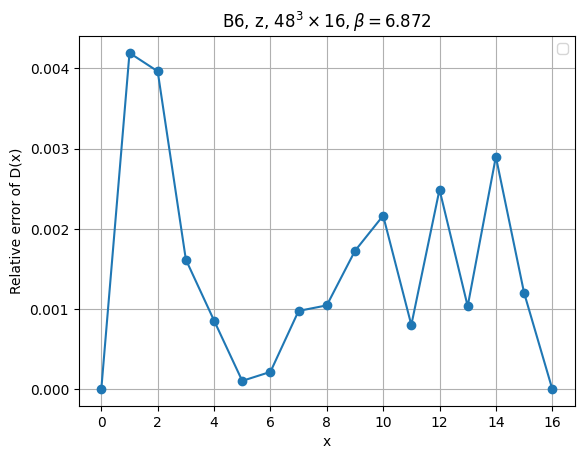

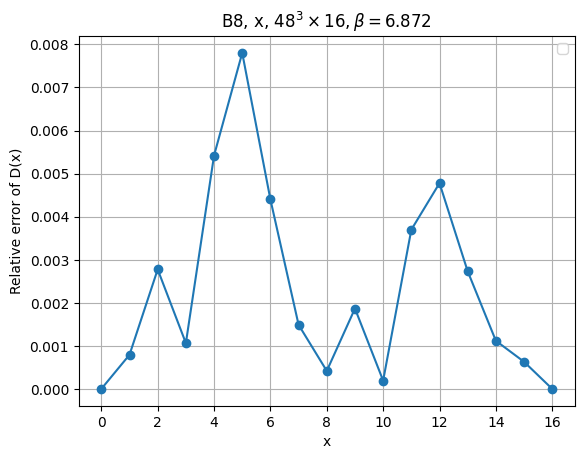

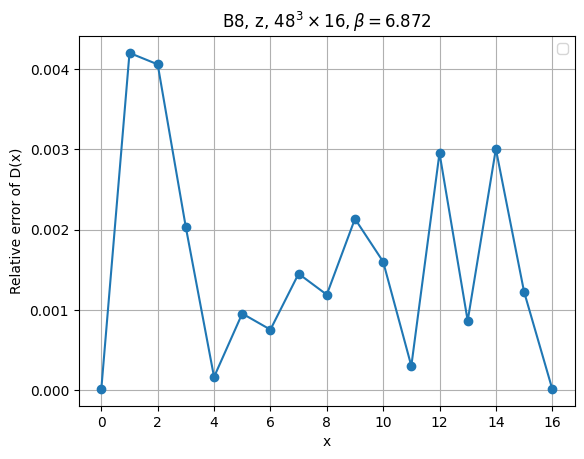

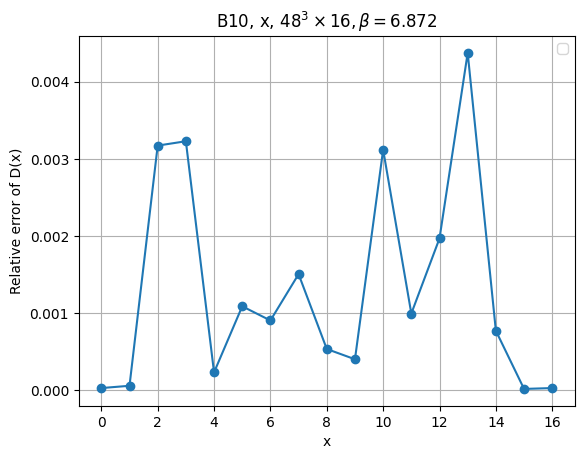

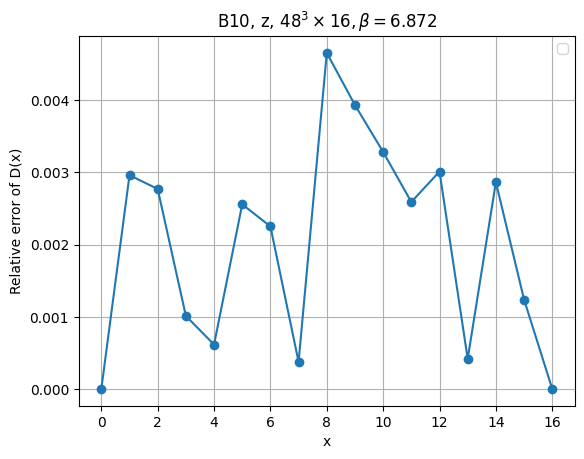

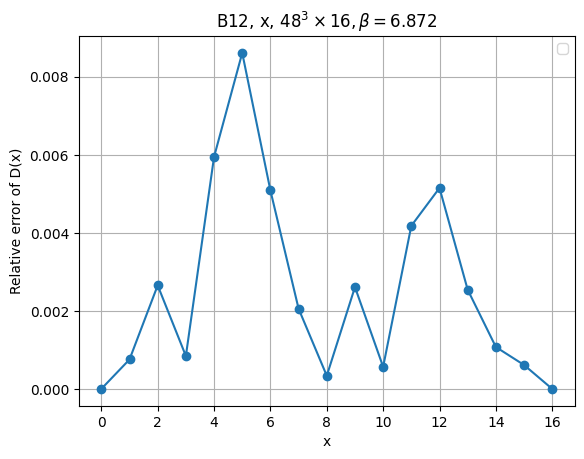

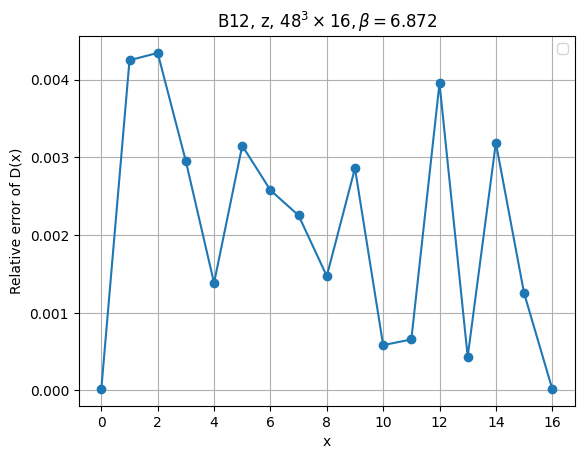

In [8]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    # plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    # plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    plt.plot(x,np.abs(mean-Dxi_reconstructed)/mean,'o-')
    plt.title(Label+r", $48^3\times 16, \beta=6.872$")
    # plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('Relative error of D(x)')
    plt.grid()
    plt.legend()
    # plt.ylim(1e-4,1e0)
    

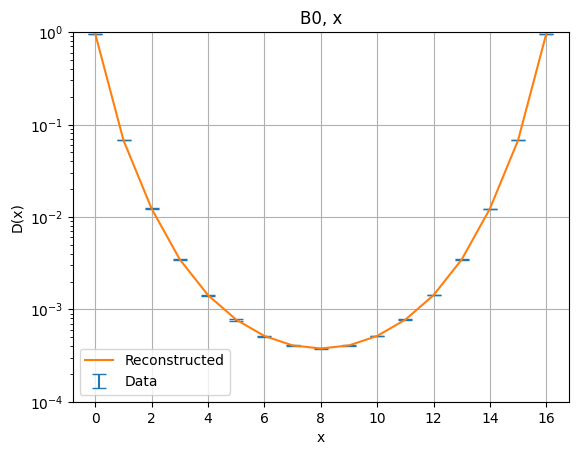

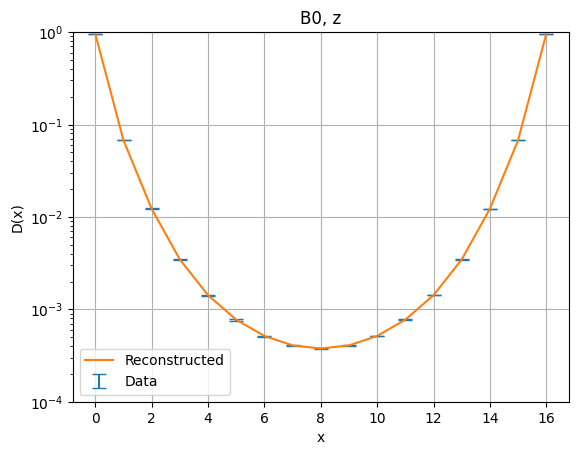

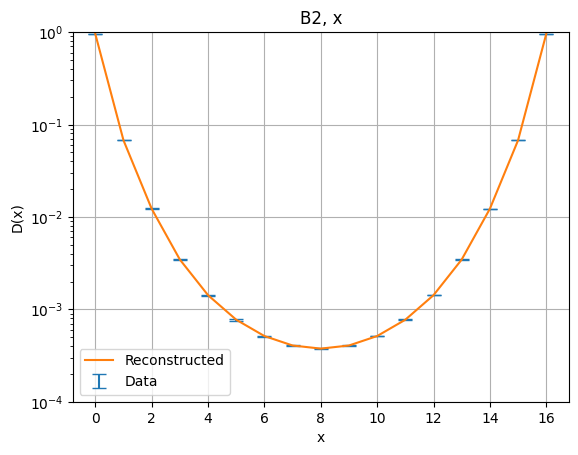

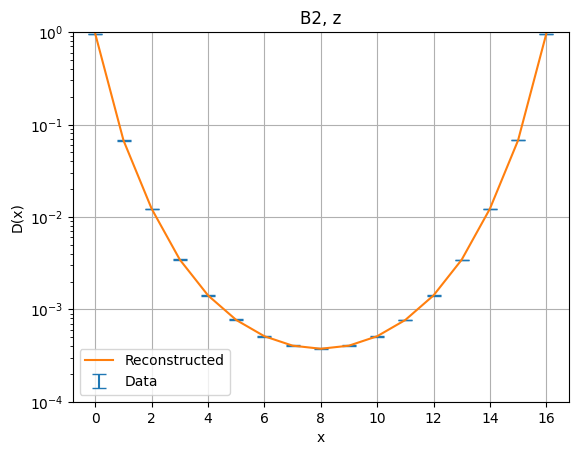

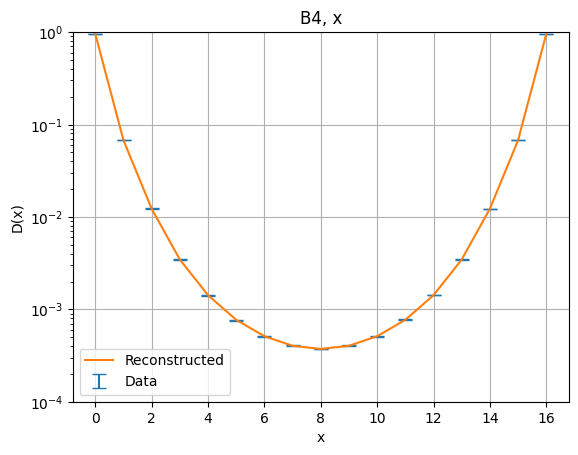

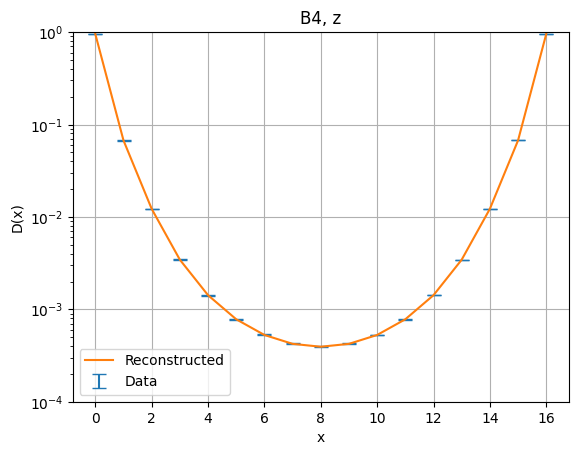

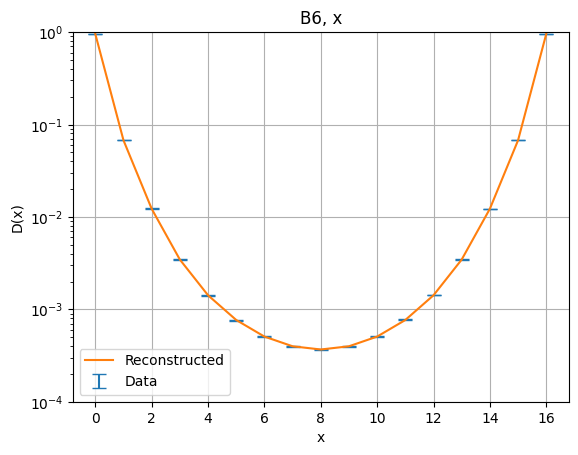

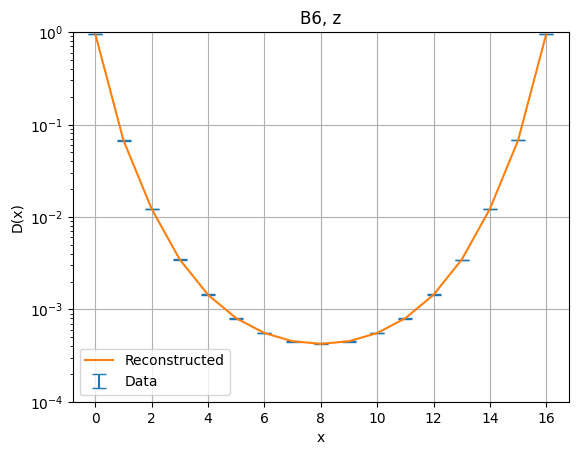

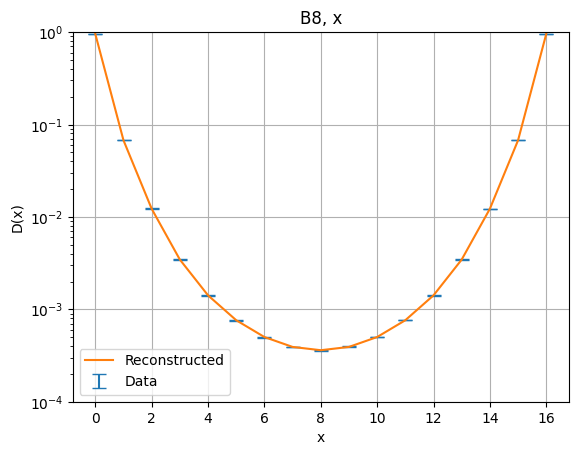

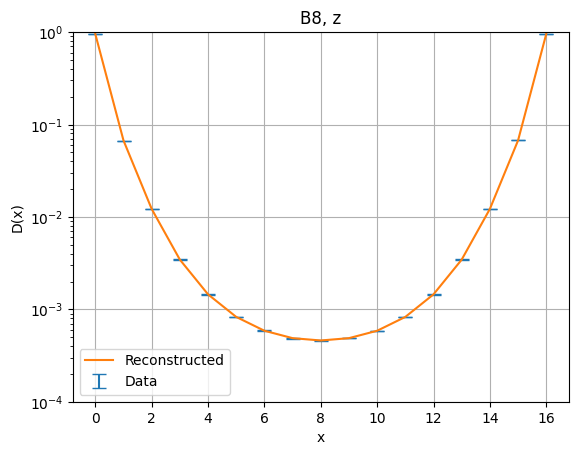

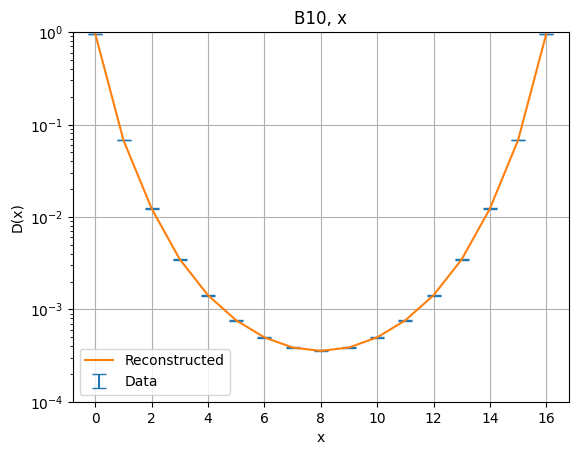

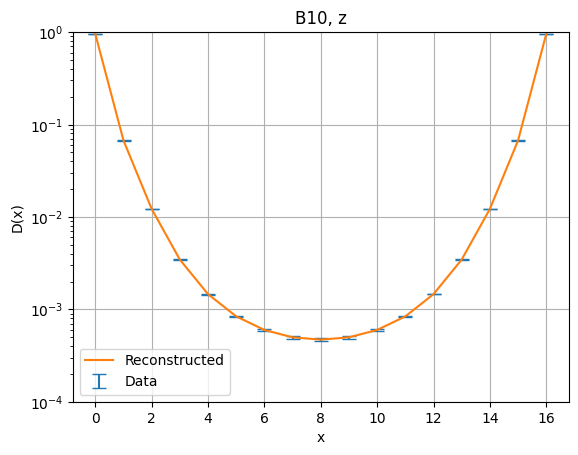

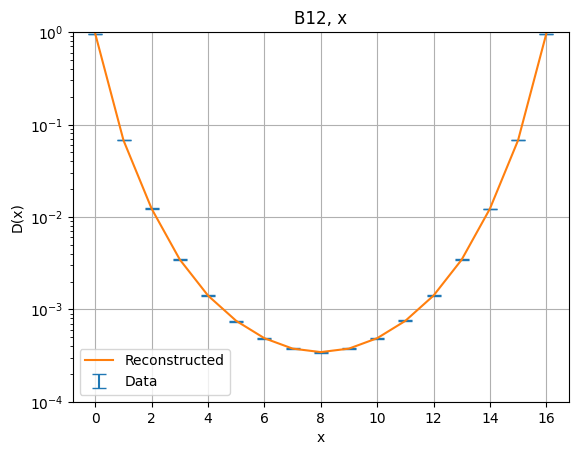

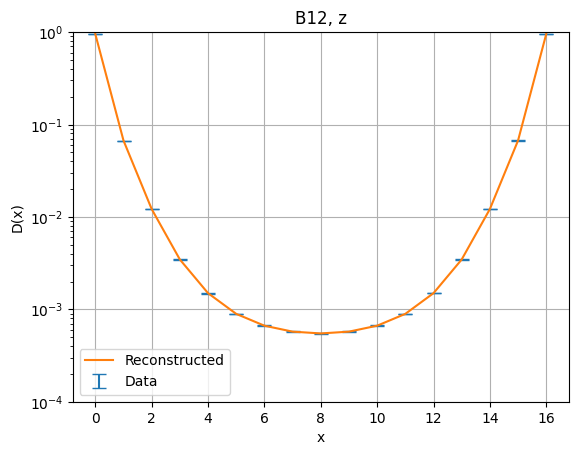

In [5]:
for (x,mean,error,jack,Label),(x_reconstructed,Dxi_reconstructed,Label) in zip(lattice_data,reconstructed_data):
    f=plt.figure()
    plt.errorbar(x, mean, yerr=error,label='Data',fmt='',ls='',capsize=5)
    plt.plot(x_reconstructed,Dxi_reconstructed,label='Reconstructed')
    plt.title(Label)
    plt.yscale('log')
    plt.xlabel('x')
    plt.ylabel('D(x)')
    plt.grid()
    plt.legend()
    plt.ylim(1e-4,1e0)